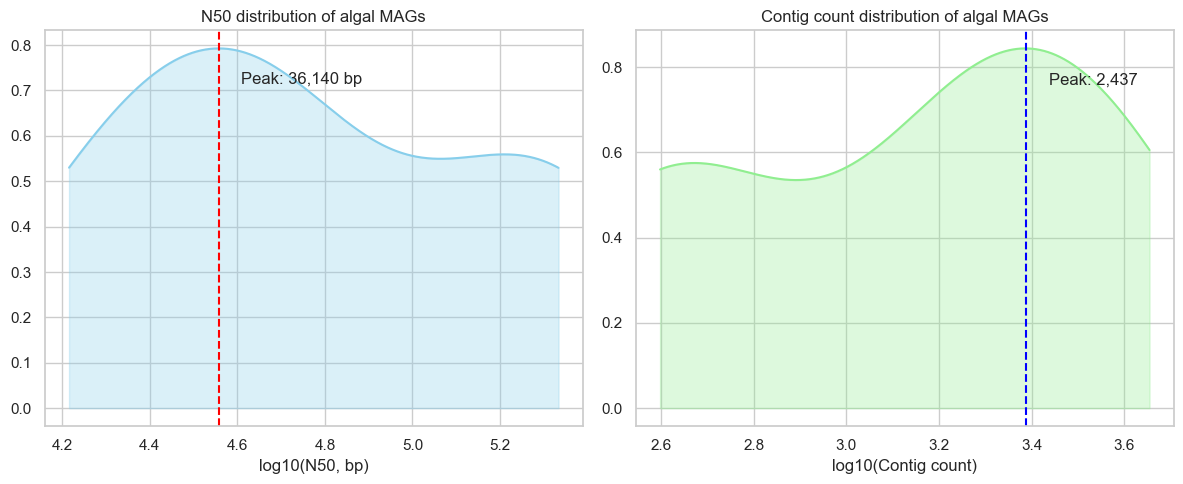

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import gaussian_kde

# 读取数据
group = 'algal'
df = pd.read_csv("report.tsv", sep="\t", index_col=0)
mag_stats = df.loc[['N50', '# contigs']].T
mag_stats.rename(columns={'N50':'N50', '# contigs':'Contig_count'}, inplace=True)

# log10 转换
mag_stats['logN50'] = np.log10(mag_stats['N50'])
mag_stats['logContigs'] = np.log10(mag_stats['Contig_count'])

# 计算 KDE
kde_N50 = gaussian_kde(mag_stats['logN50'])
kde_Contigs = gaussian_kde(mag_stats['logContigs'])

# 样本点，用于绘制密度曲线
x_N50 = np.linspace(mag_stats['logN50'].min(), mag_stats['logN50'].max(), 1000)
x_Contigs = np.linspace(mag_stats['logContigs'].min(), mag_stats['logContigs'].max(), 1000)

density_N50 = kde_N50(x_N50)
density_Contigs = kde_Contigs(x_Contigs)

# 找到峰值
peak_logN50 = x_N50[np.argmax(density_N50)]
peak_logContigs = x_Contigs[np.argmax(density_Contigs)]

peak_N50 = 10**peak_logN50
peak_Contigs = 10**peak_logContigs

# 绘图
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# N50 密度图
axes[0].plot(x_N50, density_N50, color='skyblue')
axes[0].fill_between(x_N50, density_N50, color='skyblue', alpha=0.3)
axes[0].axvline(peak_logN50, color='red', linestyle='--', label=f'Peak: {int(peak_N50):,} bp')
axes[0].set_xlabel('log10(N50, bp)')
axes[0].set_title(f"N50 distribution of {group} MAGs")
# axes[0].legend()
axes[0].annotate(f'Peak: {int(peak_N50):,} bp',
                 xy=(peak_logN50, np.max(density_N50)),
                 xytext=(peak_logN50+0.05, np.max(density_N50)*0.9))

# Contig 数密度图
axes[1].plot(x_Contigs, density_Contigs, color='lightgreen')
axes[1].fill_between(x_Contigs, density_Contigs, color='lightgreen', alpha=0.3)
axes[1].axvline(peak_logContigs, color='blue', linestyle='--', label=f'Peak: {int(peak_Contigs):,}')
axes[1].set_xlabel('log10(Contig count)')
axes[1].set_title(f'Contig count distribution of {group} MAGs')
# axes[1].legend()
axes[1].annotate(f'Peak: {int(peak_Contigs):,}',
                 xy=(peak_logContigs, np.max(density_Contigs)),
                 xytext=(peak_logContigs+0.05, np.max(density_Contigs)*0.9))

plt.tight_layout()
plt.savefig(f'n50_contig_distribution_{group}.jpg',dpi=300)

['CAXUUS010001393.1']


([], [])

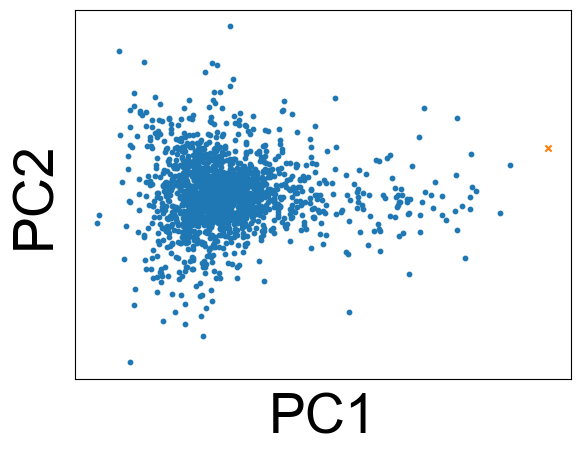

In [1]:
from Bio import SeqIO
import numpy as np
import itertools
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
import numpy as np
from scipy.stats import chi2

# 生成所有4-mer
k = 4
kmers = [''.join(p) for p in itertools.product('ACGT', repeat=k)]
kmer_index = {k:i for i,k in enumerate(kmers)}

def kmer_count(seq):
    vec = np.zeros(len(kmers))
    seq = str(seq).upper()
    for i in range(len(seq)-k+1):
        kmer = seq[i:i+k]
        if kmer in kmer_index:
            vec[kmer_index[kmer]] += 1
    if vec.sum() > 0:
        vec = vec / vec.sum()
    return vec

names = []
X = []


for record in SeqIO.parse("GCA_964254445.1_public_SRR14722103_metabat2_bin.2_genomic.fasta", "fasta"):
    if len(record.seq) > 2000:
        names.append(record.id)
        X.append(kmer_count(record.seq))

X = np.array(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

mean = np.mean(X_pca, axis=0)
cov_matrix = np.cov(X_pca.T)
inv_cov = inv(cov_matrix)

# Mahalanobis distance
dist = []
for x in X_pca:
    d = mahalanobis(x, mean, inv_cov)
    dist.append(d)

dist = np.array(dist)
# threshold = np.mean(dist) + 2 * np.std(dist)
threshold = chi2.ppf(0.95, df=2)
keep_idx = dist <= threshold
remove_idx = dist > threshold
good_contigs = np.array(names)[keep_idx]
bad_contigs = np.array(names)[remove_idx]
print(bad_contigs)

# 画图
plt.scatter(
    X_pca[keep_idx, 0],
    X_pca[keep_idx, 1],
    s=10,
    label="good"
)

# bad contigs（高亮）
plt.scatter(
    X_pca[remove_idx, 0],
    X_pca[remove_idx, 1],
    s=20,
    marker="x",
    label="bad"
)

# plt.xlabel("PC1", fontsize=40, fontname="Arial", labelpad=10)
# plt.ylabel("PC2", fontsize=40, fontname="Arial", labelpad=10)
plt.xticks([])
plt.yticks([])
# plt.legend()
# plt.show()
# plt.savefig('tetrafreq_example.jpg',dpi=300)

In [16]:
import pandas as pd

category = {}
for line in open('197magname.txt','r'):
    linstrip = line.strip().split('\t')
    category[linstrip[0]] = linstrip[1]
    
badlist = []
for line in open('kmerfreq_total_4mer','r'):
    if len(line.strip().split('\t')) > 1:
        if line.startswith('GCA'):
            for k in line.strip().split('\t')[1].split(','):
                badlist.append(f"{line.strip().split('\t')[0]}.1|{k}")
        else:
            for k in line.strip().split('\t')[1].split(','):
                badlist.append(f"{line.strip().split('\t')[0]}|{k}")

df = pd.read_csv("gene_on_contig0422", sep="\t")
badset = set(badlist)

result = {"fungi": 0, "algae": 0}
with open("gene_on_contig0422", "r") as f:
    next(f)  # 跳表头

    for line in f:
        parts = line.strip().split("\t")
        contig = parts[0]

        total_gene = int(parts[1])
        flag20k = parts[5]   # 按你列位置确认

        if flag20k != "1":
            continue

        if contig in badset:
            continue

        # 提取 sample
        sample = contig.split("|")[0]

        # category 分类
        ctype = category.get(sample)
        if ctype is None:
            continue

        result[ctype] += total_gene

print(result)

{'fungi': 914046, 'algae': 75233}


In [19]:
import pandas as pd

# 读入 main
df = pd.read_csv("gene_on_contig0422", sep="\t")

# 提取 sample（不改原 Contig，只生成新列）
df["sample"] = df["Contig"].str.split("|").str[0]

# 如果需要统一 GCA + .1
df.loc[df["sample"].str.startswith("GCA"), "sample"] += ".1"

# 按 sample 统计 total gene
result = df.groupby("sample")["Total_gene"].sum()

# 输出
print(result)
result.to_csv("sample_total_gene.tsv", sep="\t", header=True)

sample
20180047_Refined_2       9058
20191382_Refined_6       7655
20191388_Refined_4       7361
20191857_Refined_1       6673
20210929_Refined_4      10349
                        ...  
NJ20180008_Refined_1     7031
NMG2015044_Refined_2    10984
RQ5379_Refined_2         8617
SPT1203_Refined_3        6649
Um_Refined_7             6902
Name: Total_gene, Length: 197, dtype: int64


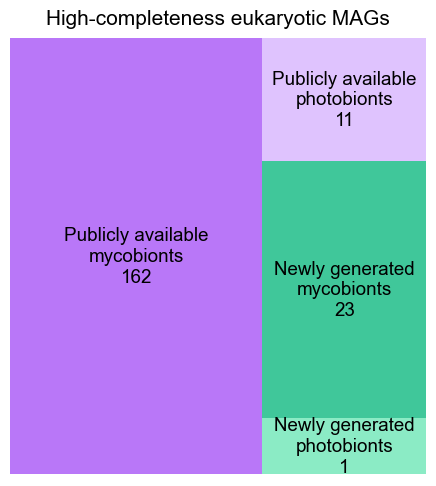

In [11]:
import squarify
import pandas as pd
import matplotlib.pyplot as plt

# 数据
value2 = [60,5,23,11]
data = {
    'category': ['Publicly available\nmycobionts', 'Newly generated\nphotobionts','Newly generated\nmycobionts', 'Publicly available\nphotobionts',],
    'value': [162,1,23,11],
    'color': ['#A855F7','#6EE7B7','#10B981', '#D8B4FE']
}

plt.figure(figsize=(4.5, 5))
squarify.plot(sizes=value2,
              label=[f"{cat}\n{val}" for cat, val in zip(data['category'], data['value'])],
              color=data['color'],
              alpha=0.8,
              text_kwargs={'fontsize': 13.5,'fontfamily':'Arial'})

plt.axis('off')
plt.title('High-completeness eukaryotic MAGs', fontsize=15,family = 'Arial',pad=10)
plt.tight_layout()
# plt.show()
plt.savefig('mag-treemap.svg',dpi=300,format='svg')


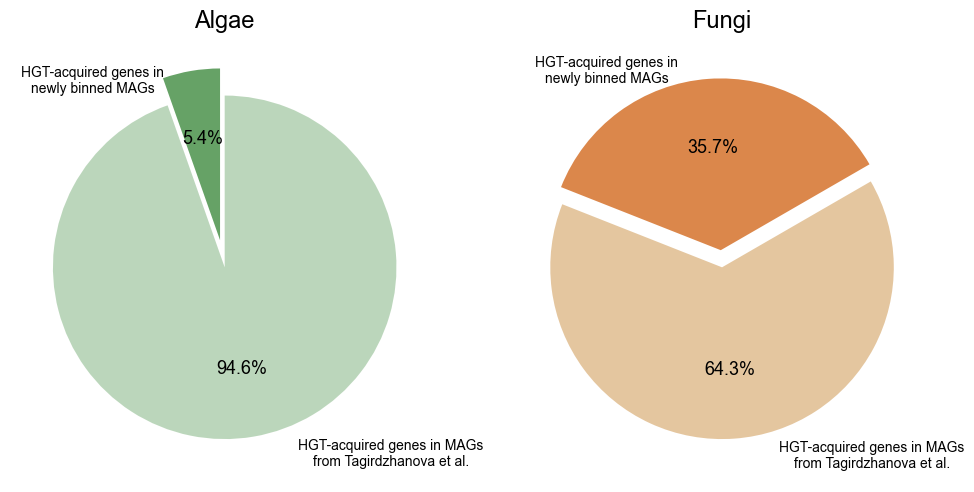

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"

# 读取 Excel
df = pd.read_csv("target_gene_annotation2021.tsv", sep="\t")
keyword = 'Refined'

df['Gene'] = df['Gene'].astype(str)
df = df[df["confidence"] == 'high-confidence'].copy()

df_algae = df[df['Source'] == 'algae']
df_fungi = df[df['Source'] == 'fungi']

target_count = df_algae['Gene'].str.contains(keyword, na=False).sum()
others_count = len(df_algae) - target_count
sizes = [target_count, others_count]

target2 = df_fungi['Gene'].str.contains(keyword, na=False).sum()
others2 = len(df_fungi) - target2
sizes2 = [target2, others2]

labels = ['HGT-acquired genes in\nnewly binned MAGs', 'HGT-acquired genes in MAGs\nfrom Tagirdzhanova et al.']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

wedges1, texts1, autotexts1 = axes[0].pie(
    sizes,
    explode = [0.16, 0],
    startangle=90,
    autopct='%1.1f%%',
    colors=['#006400','#8FBC8F'],
    textprops={'fontsize': 13}
)

y_offsets1 = [0.1, -0.1]  # 每个label不同上下偏移
x_offsets1 = [-0.6,0.8]
y_offsets2 = [0.2, -0.05]

for w in wedges1:
    w.set_alpha(0.6)

for i, w in enumerate(wedges1):
    ang = (w.theta2 + w.theta1) / 2
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))

    axes[0].annotate(
        labels[i],
        xy=(x, y),
        xytext=(x + x_offsets1[i], y + y_offsets1[i]),
        ha='center',
        va='center'
    )

axes[0].set_title("Algae", fontsize=17, pad=18)
axes[0].set_aspect('equal')

wedges2, texts2, autotexts2 = axes[1].pie(
    sizes2,
    autopct='%1.1f%%',
    explode=[0.1, 0],
    # colors=['#00688B', '#87CEEB'],
    colors=['chocolate', '#DEB887'],

    startangle=30,
    textprops={'fontsize': 13}
)
for w in wedges2:
    w.set_alpha(0.8)

for i, w in enumerate(wedges2):
    ang = (w.theta2 + w.theta1) / 2
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))

    axes[1].annotate(
    labels[i],
    xy=(x, y),
    xytext=(x + x_offsets1[i], y + y_offsets2[i] - 0.05),
    ha='center',
    va='center'
    )

axes[1].set_title("Fungi", fontsize=17, pad=18)
axes[1].set_aspect('equal')

plt.tight_layout()

# plt.show()
plt.savefig('newly2total.jpg',dpi=300)

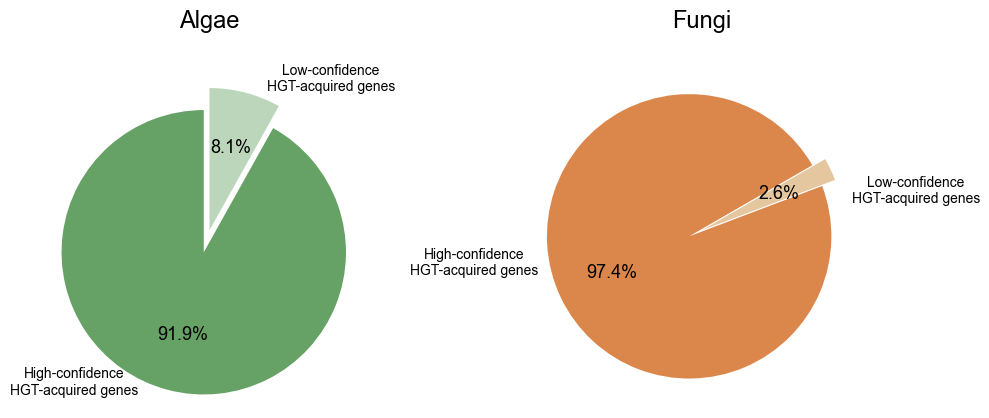

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"

# 读取 Excel
df = pd.read_csv("target_gene_annotation2021.tsv", sep="\t")

df['Gene'] = df['Gene'].astype(str)

df_algae = df[df['Source'] == 'algae']
df_fungi = df[df['Source'] == 'fungi']

high_count = (df_algae['confidence'] == 'high-confidence').sum()
low_count = (df_algae['confidence'] == 'low-confidence').sum()
sizes = [high_count, low_count]

high_count2 = (df_fungi['confidence'] == 'high-confidence').sum()
low_count2 = (df_fungi['confidence'] == 'low-confidence').sum()
sizes2 = [high_count2, low_count2]

labels = ['High-confidence\nHGT-acquired genes', 'Low-confidence\nHGT-acquired genes']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

wedges1, texts1, autotexts1 = axes[0].pie(
    sizes,
    explode = [0.16, 0],
    startangle=90,
    autopct='%1.1f%%',
    colors=['#006400','#8FBC8F'],
    textprops={'fontsize': 13}
)

y_offsets1 = [-0.1, 0.1]  # 每个label不同上下偏移
x_offsets1 = [-0.7,0.6]
y_offsets2 = [0.2, -0.15]

for w in wedges1:
    w.set_alpha(0.6)

for i, w in enumerate(wedges1):
    ang = (w.theta2 + w.theta1) / 2
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))

    axes[0].annotate(
        labels[i],
        xy=(x, y),
        xytext=(x + x_offsets1[i], y + y_offsets1[i]),
        ha='center',
        va='center'
    )

axes[0].set_title("Algae", fontsize=17, pad=18)
axes[0].set_aspect('equal')

wedges2, texts2, autotexts2 = axes[1].pie(
    sizes2,
    autopct='%1.1f%%',
    explode=[0.1, 0],
    # colors=['#00688B', '#87CEEB'],
    colors=['chocolate', '#DEB887'],
    startangle=30,
    textprops={'fontsize': 13}
)
for w in wedges2:
    w.set_alpha(0.8)

for i, w in enumerate(wedges2):
    ang = (w.theta2 + w.theta1) / 2
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))

    axes[1].annotate(
    labels[i],
    xy=(x, y),
    xytext=(x + x_offsets1[i], y + y_offsets2[i]),
    ha='center',
    va='center'
    )

axes[1].set_title("Fungi", fontsize=17, pad=18)
axes[1].set_aspect('equal')

plt.tight_layout()

# plt.show()
plt.savefig('highlowconfidence.svg',dpi=300,format='svg')

1882
Source    algae  fungi
COG_list              
-            88     43
A            22      0
B             8      0
C            68     17
D             6      7
E           137     13
F            22      6
G           121     55
H            36      8
I            82     41
J            83     11
K            36     56
L            72     15
M            56     70
N             1      0
O           112     24
P            35      9
Q           142     51
S           343     70
T            51      6
U            19      6
V            11     11
Z             4      0 Source
algae    1428
fungi     454
Name: Gene, dtype: int64


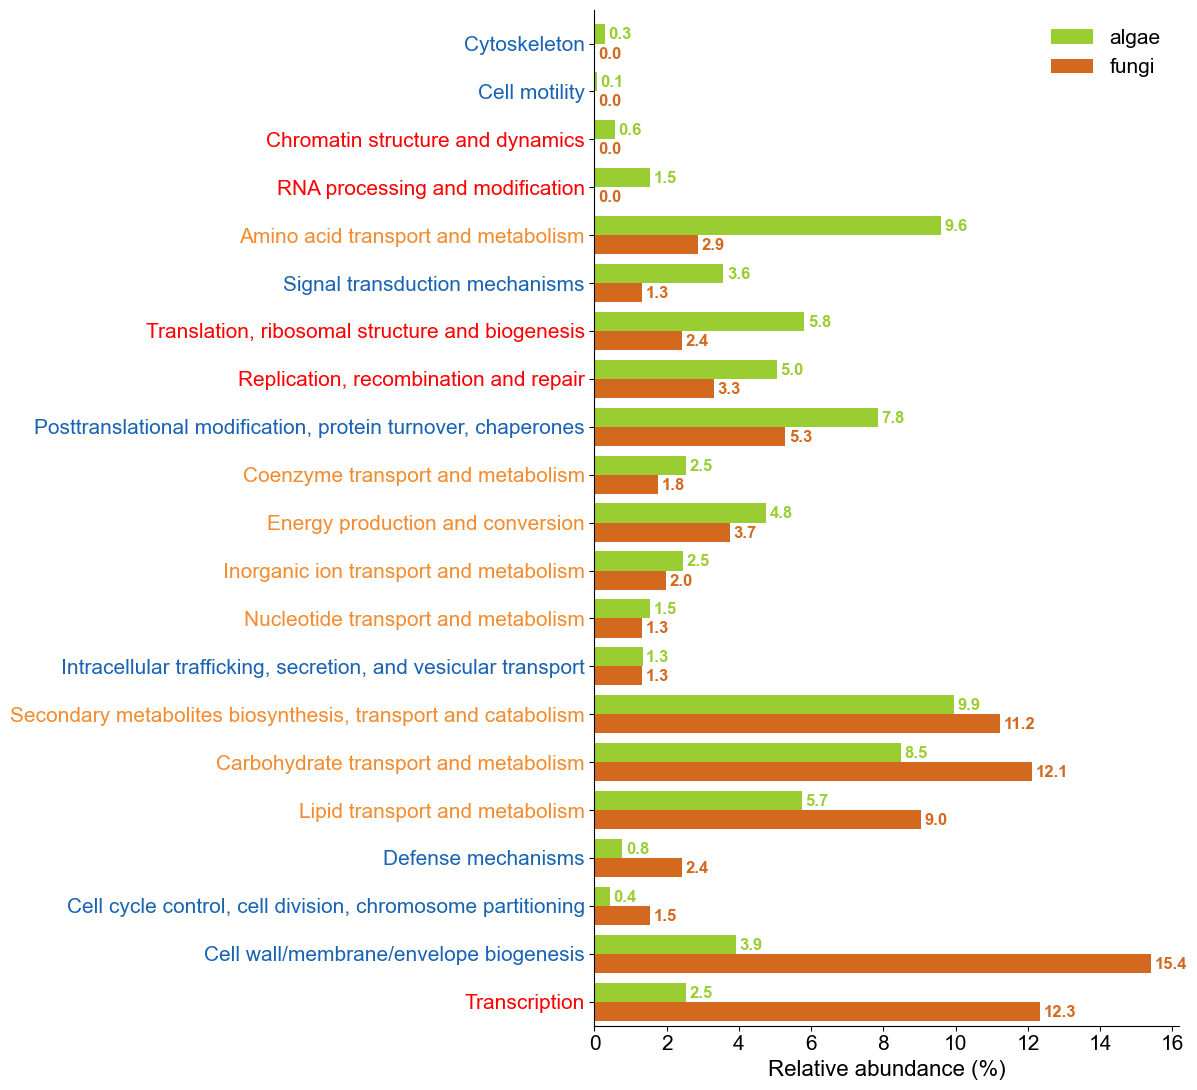

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

# 只保留需要的列
df = pd.read_csv("target_gene_annotation2021.tsv", sep="\t")
df = df[df["confidence"] == 'high-confidence'].copy()
print(len(df))
gene_total = df.groupby("Source")["Gene"].nunique()
df = df[["Source", "COG_category", "Gene"]].copy()
df["COG_category"] = df["COG_category"].fillna("-")
df["COG_list"] = df["COG_category"].apply(lambda x: list(x) if x != "-" else ["-"])
df_exploded = df.explode("COG_list").reset_index(drop=True)


cog_counts = df_exploded.groupby(["COG_list", "Source"])["Gene"].nunique().unstack(fill_value=0)

cog_ratio = cog_counts.div(gene_total, axis=1) * 100

cog_ratio["ratio"] = cog_ratio["fungi"] / cog_ratio["algae"].replace(0, float("inf"))
cog_ratio = cog_ratio.sort_values("ratio", ascending=False)
print(cog_counts, gene_total)
cogcat = {}
cogcolor = {}
upper = ''

for line in open('D:/research_files/lichen metagenome/COG category.txt'):
    line = line.strip()
    if not line:
        continue
    if line.isupper():
        upper = line
    else:
        m = re.search(r'\[([A-Z])\]\s(.*)', line)
        if m:
            cogcat[m.group(1)] = m.group(2)
            cogcolor[m.group(2)] = upper

# 映射
cog_ratio["label"] = cog_ratio.index.map(lambda x: cogcat.get(x, "Unannotated"))
remove = {"-", "unannotated", "unknown", "Function unknown"} 
plot_ratio = cog_ratio.loc[ ~cog_ratio.index.str.lower().isin(remove) ]

remove_one = {"S"}

plot_ratio = plot_ratio.loc[~plot_ratio.index.isin(remove_one)]

fig, ax = plt.subplots(figsize=(12, 11))
font_prop = dict(size = '15',family = 'Arial', weight = 'light')
font2 = dict(size = '12',family = 'Arial', weight = 'bold',style='normal')
font_dict = dict(fontsize = '18', family = 'Arial', weight = 'light',style = 'normal')
ax.set_ylim(-0.5, len(plot_ratio) - 0.3)

y = np.arange(len(plot_ratio))
height = 0.4

fungi = plot_ratio["fungi"].values
algae = plot_ratio["algae"].values
labels = plot_ratio["label"].values

bar1 = ax.barh(y - height/2, fungi, height=height, label='fungi', color='chocolate')
bar2 = ax.barh(y + height/2, algae, height=height, label='algae', color='yellowgreen')

# 数值标注
for i in range(len(y)):
    ax.text(fungi[i] + 0.1, y[i] - height/2-0.02, f"{fungi[i]:.1f}", va='center',fontdict=font2, color='chocolate')
    ax.text(algae[i] + 0.1, y[i] + height/2-0.02, f"{algae[i]:.1f}", va='center',fontdict=font2, color='yellowgreen')

# y轴标签
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=12,font='Arial',size='15')
for label in ax.get_xticklabels():
    label.set_fontname('Arial')
ax.tick_params(axis='x', labelsize=15)

# 上色（COG大类）
for label in ax.get_yticklabels():
    text = label.get_text()
    if text in cogcolor:
        if cogcolor[text] == 'INFORMATION STORAGE AND PROCESSING':
            label.set_color('red')
        elif cogcolor[text] == 'CELLULAR PROCESSES AND SIGNALING':
            label.set_color('#1963B3')
        elif cogcolor[text] == 'METABOLISM':
            label.set_color('#F38B2F')

ax.set_xlabel('Relative abundance (%)',fontsize=16,fontname='Arial')
ax.legend(prop = font_prop,loc='upper right',frameon=False,handles=[bar2,bar1])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# plt.title('Relative abundance of COG categories',font = 'Arial',size = '12', x=-1)
plt.tight_layout()
# plt.show()
plt.savefig('relativeabundance_hc.png',dpi=300)

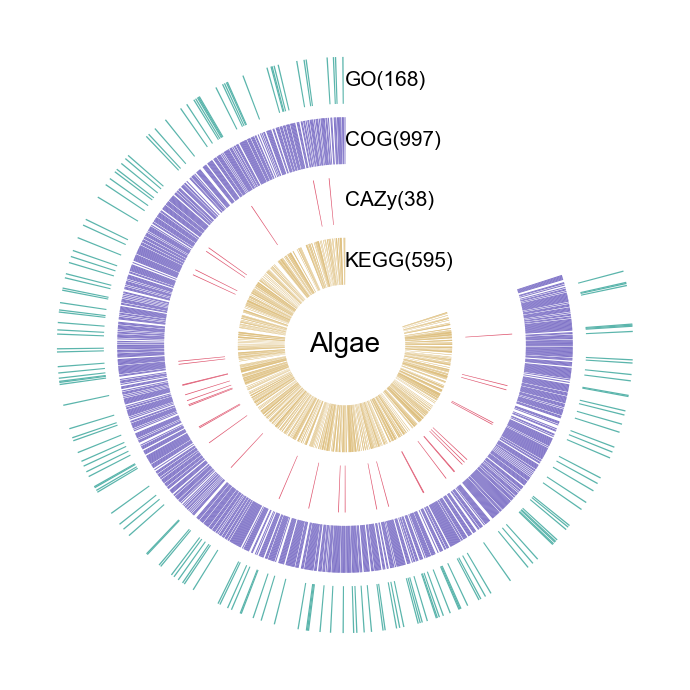

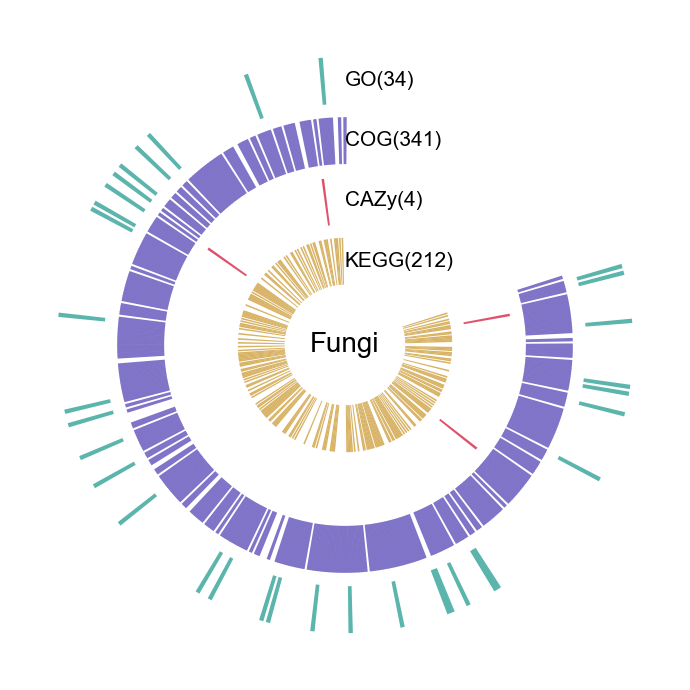

In [32]:
df = pd.read_csv("target_gene_annotation2021.tsv", sep="\t")
column_names = ["Contig","Total_gene", "Target_gene", "Ratio", "Target_gene_list", "20k", "nonHGT_taxids",
                "nonHGT_organism", "nonHGT_nontargetorg", "nonHGT_ratio", "confidence", "Gene","MMSH_iden",
                "MMSH","MMSH_taxid","bbhO","Donor", "query", "COG_category", "Description","GOs", "EC", "KEGG_ko",
    "KEGG_Pathway", "KEGG_Module", "KEGG_Reaction", "KEGG_rclass", "BRITE",
    "KEGG_TC", "CAZy", "PFAMs", "Source"
]

df.columns = column_names
df = df[df["confidence"] == 'high-confidence'].copy()

db_cols = {
    "KEGG": ["KEGG_ko", "KEGG_Pathway", "KEGG_Module", "KEGG_Reaction", "KEGG_rclass", "BRITE", "KEGG_TC"],
    "GO": ["GOs"],
    "COG": ["COG_category"],
    "CAZy": ["CAZy"]
}
data = {"gene": df["query"].tolist()}
for db, cols in db_cols.items():
    data[db] = []
    for _, row in df.iterrows():
        has_anno = any((pd.notna(row[c]) and row[c] != "-") for c in cols if c in df.columns)

        if db == "COG" and row["COG_category"] == "S":
            has_anno = False

        data[db].append(1 if has_anno else 0)

matrix = pd.DataFrame(data)
# matrix.to_csv('output_file.csv', index=False)

algae_df = matrix[matrix["gene"].str.startswith("algae")]
fungi_df = matrix[matrix["gene"].str.startswith("fungi")]
# ====== 画图准备 ======
def plot_circular(df,title):
    n_genes = len(df)

    theta = np.linspace(0, 1.6 * np.pi, n_genes, endpoint=False)
    db_list = ["KEGG", "CAZy", "COG","GO"]
    n_rings = len(db_list)
    colors = ["#D8B365","#DE526C","#8074C8",  "#5BB5AC"]

    db_counts = {
    col: int(df[col].sum())
    for col in db_list
    }

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
    ring_width = 0.7
    gap = 0.2
    ax.set_theta_direction(1)
    ax.set_theta_offset(np.pi / 2.0)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylim(0, n_rings +1)
    ax.spines['polar'].set_visible(False)

    # 画每一圈
    for i, col in enumerate(db_list, start=1):
        bottom = i * (ring_width + gap)
        values = df[col].values
        for j, val in enumerate(values):
            if val == 1:
                ax.bar(theta[j], ring_width, width=2 * np.pi / n_genes,
                       bottom=bottom, color=colors[i - 1], edgecolor="none", linewidth=0.5,alpha=1)
                
        bottom = i * (ring_width + gap) + ring_width / 2

        ax.text(
            0,  # theta=0（起始位置）
            bottom,
            f"{col}({db_counts[col]})",
            ha="left",
            va="center",
            fontsize=15,
            fontweight="normal",
            fontfamily="Arial",
            rotation=0
        )

    # 图例
    # for i, col in enumerate(db_list):
    #     ax.bar(0, 0, color=colors[i], label=col)
    # ax.legend(loc="upper right", bbox_to_anchor=(1.1, 1.1))

    # plt.title(title, y=1.1)
    ax.text(
    0.5, 0.5,
    title,
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=20,
    fontweight="normal",
    # fontfamily="Arial" 
)
    plt.tight_layout()
    # plt.show()
    plt.savefig(f"{title}_hc.svg",dpi=300,format="svg")
plot_circular(algae_df,'Algae')
plot_circular(fungi_df,'Fungi')

In [9]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("target_gene_annotation.tsv", sep="\t")

target_source = "fungi"
df = df[df["Source"] == target_source]
df = df[~df["MMSH Taxonomy"].str.contains("donorconfusion", na=False)]

def split_tax(x):
    if pd.isna(x):
        return []
    return [i.strip() for i in str(x).split(";") if i.strip()]

node_counter = {}
parent_map = {}

max_depth = 3

for tax in df["MMSH Taxonomy"]:
    levels = split_tax(tax)[:max_depth]

    for i, lv in enumerate(levels):
        # ✅ 统计节点 count
        node_counter[lv] = node_counter.get(lv, 0) + 1

        # ✅ 建立 parent（只记录一次即可）
        if i == 0:
            parent_map[lv] = ""
        else:
            parent_map[lv] = levels[i-1]

data = []

for name, count in node_counter.items():
    data.append({
        "character": name,
        "parent": parent_map.get(name, ""),
        "value": count
    })

tree_df = pd.DataFrame(data)
threshold = 5
tree_df["character"] = tree_df.apply(
    lambda x: x["character"] if x["value"] >= threshold else "",
    axis=1
)
fig = px.sunburst(
    tree_df,
    names='character',
    parents='parent',
    values='value',
)

fig.update_traces(
    marker=dict(
        line=dict(color="white", width=1)
    )
)

fig.update_traces(
    textinfo="label"
)

fig.write_html("sunburst.html")

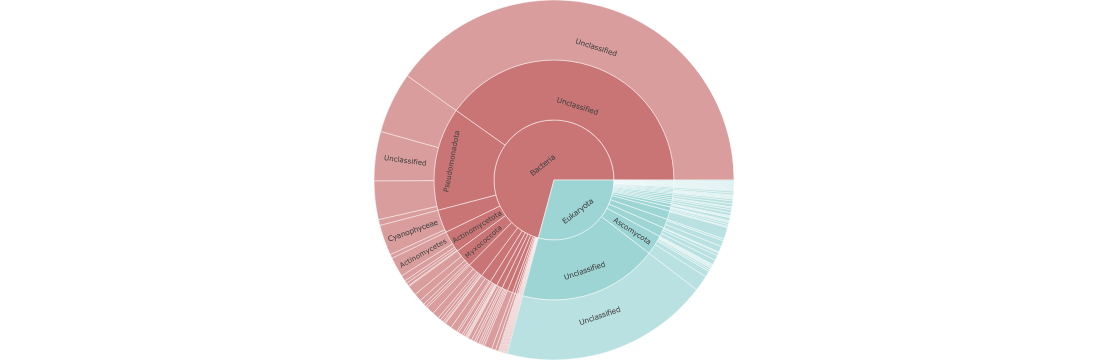

In [1]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("target_gene_annotation2021.tsv", sep="\t")
df = df[df["confidence"] == 'high-confidence'].copy()

target_source = "algae"
df = df[df["Source"] == target_source]
df = df[~df["Donor"].str.contains("donorconfusion", na=False)]

def split_tax(x):
    if pd.isna(x):
        return []
    return [i.strip() for i in str(x).split(";") if i.strip()]

rows = []
max_depth = 3

for tax in df["Donor"]:
    levels = split_tax(tax)

    # 截断到3层
    levels = levels[:max_depth]

    # 补齐到3层（关键：Unclassified占位）
    levels += ["Unclassified"] * (max_depth - len(levels))

    rows.append(levels)

sunburst_df = pd.DataFrame(rows, columns=["level1", "level2", "level3"])

# 每条路径计数
sunburst_df["value"] = 1

# 合并重复路径
sunburst_df = sunburst_df.groupby(
    ["level1", "level2", "level3"],
    as_index=False
)["value"].sum()

# 只在大于阈值时显示label（可选）
# threshold = 10

# sunburst_df["label"] = sunburst_df.apply(
#     lambda x: "" if x["value"] < threshold else x["level3"],
#     axis=1
# )

fig = px.sunburst(
    sunburst_df,
    path=["level1", "level2", "level3"],
    values="value",
    color="level1",
    color_discrete_map={
        "Bacteria": "#C97475",
        "Eukaryota": "#9DD5D5",
        "Viruses": "#a080f5",
    }
)

fig.update_traces(
    marker=dict(
        line=dict(color="white", width=0.5)
    )
)
fig.update_layout(uniformtext=dict(minsize=7, mode='hide'))
fig.update_layout(
    margin=dict(t=0, l=0, r=0, b=0)
)
# fig.write_image("algae-sunburst.svg")
# fig.write_html('algae.html')
fig.show()

215
按Order分组后的统计量（中位数和均值）：
        Metric Statistic  Order_0  Order_1
Breakpoint_cov    median    21.00    18.00
Breakpoint_cov      mean   116.04   118.56
      Left_cov    median    19.57    21.05
      Left_cov      mean   114.44   122.71
     Right_cov    median    22.06    19.45
     Right_cov      mean   121.98   117.84
Crossing_reads    median    14.00    14.00
Crossing_reads      mean    84.49    84.44
           Pos    median 22734.00 20355.00
           Pos      mean 40906.56 39022.50
84.46652719665272


C:\Users\Yaran Zhang\AppData\Local\Temp\ipykernel_44060\3937077271.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.stripplot(x='Order', y='Crossing_reads_log', data=df_plot, palette='Set2', size=3, jitter=0.1, zorder=10)


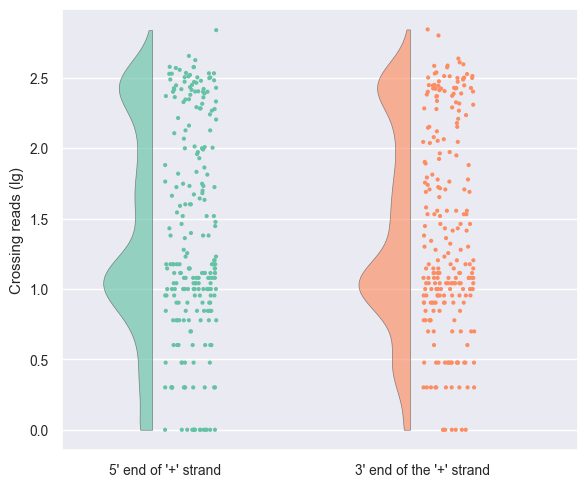

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 读取excel
df = pd.read_excel("D:/research_files/lichen metagenome/breakp_data_update.xlsx")
df['combined'] = df['Sample'].astype(str) + '_' + df['Gene'].astype(str) + '.t1'

df2 = pd.read_csv("target_gene_annotation2021.tsv", sep="\t")
df2 = df2[df2["confidence"] == 'high-confidence'].copy()
keyword = 'Refined'
df2['Gene'] = df2['Gene'].astype(str)
df2 = df2[df2['Gene'].str.contains(keyword, case=False, na=False)]
df2['Gene'] = df2['Gene'].str.replace(r'_Refined_\d+', '', regex=True)

df_sub = df[df['combined'].isin(df2['Gene'])]

numeric_columns = ['Breakpoint_cov', 'Left_cov', 'Right_cov', 'Crossing_reads', 'Pos']
# 批量转换
for col in numeric_columns:
    df_sub[col] = pd.to_numeric(df_sub[col], errors='coerce')
pivot_df = df_sub.pivot_table(index='Gene', columns='Order', values='Crossing_reads', aggfunc='first')
pivot_df.columns = pivot_df.columns.astype(int)
qualified_genes = pivot_df[(pivot_df[0] >= 1) & (pivot_df[1] >= 1)].index
count = len(qualified_genes)
print(count)
df_sub['Order'] = df_sub['Order'].astype(str).map({'0': "5' end of '+' strand", '1': "3' end of the '+' strand"})
df_plot = df_sub.copy()
df_plot['Crossing_reads_log'] = np.log10(df_plot['Crossing_reads']+1)
df_plot['Breakpoint_cov_log'] = np.log10(df_plot['Breakpoint_cov']+1)
df_plot['Left_cov_log'] = np.log10(df_plot['Left_cov']+1)
df_plot['Right_cov_log'] = np.log10(df_plot['Right_cov']+1)

order_stats = df_sub.groupby('Order')[numeric_columns].agg(['median', 'mean']).round(2)

# 重新组织结果表格
result = order_stats.T.reset_index()

result.columns = ['Metric', 'Statistic', 'Order_0', 'Order_1']

# 打印结果
print("按Order分组后的统计量（中位数和均值）：")
print("=" * 60)
print(result.to_string(index=False))

print(df_sub["Crossing_reads"].mean())
sns.set_theme(font_scale = 0.9, font = 'Arial',style = 'darkgrid')


f, ax = plt.subplots(figsize=(6, 5))

ax=pt.half_violinplot(x='Order', y='Crossing_reads_log', data=df_plot, palette='Set2', bw=.2, cut=0., scale="area", alpha=0.65,width=.4,linewidth=0.5, inner=None)
ax=sns.stripplot(x='Order', y='Crossing_reads_log', data=df_plot, palette='Set2', size=3, jitter=0.1, zorder=10)

new_pos = [t-0.1 for t in ax.get_xticks()]
ax.set_xticks(new_pos)
ax.set_xticklabels(df_plot['Order'].unique())

ax.set_ylabel("Crossing reads (lg)")
plt.xlabel('')

# plt.title('Violin Plot of Crossing Reads by Order')
# sns.kdeplot(data=df[df["Order"] == "0"]['Crossing_reads'].astype(int), shade=True,color="#016392", label="5' end on the '+' strand")
# sns.kdeplot(data=nativecontigtotalength, shade=True,color="coral", label="native contigs")
plt.tight_layout()
# plt.show()
plt.savefig('crossingreads_lg_hc.png',dpi=300,bbox_inches='tight', pad_inches=0.1)
# plt.close('all')

215


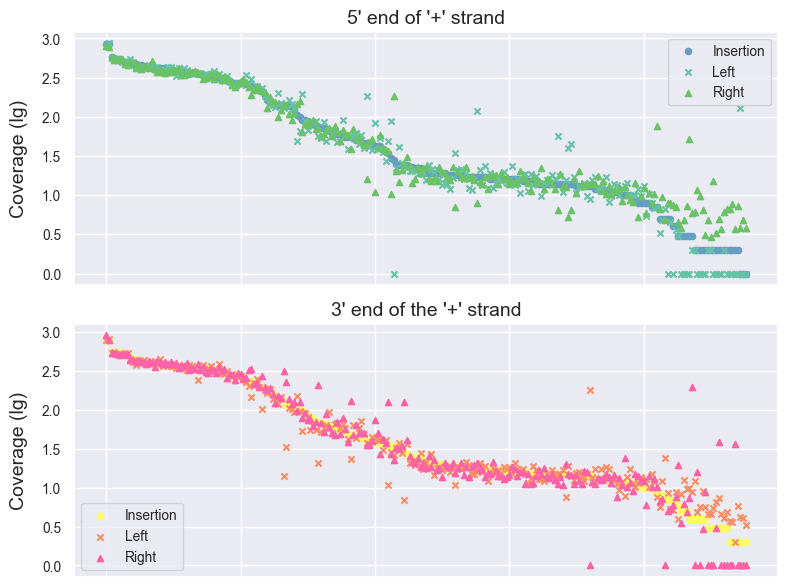

In [40]:
import matplotlib.colors as mcolors
from colorsys import rgb_to_hsv, hsv_to_rgb

fig, axes = plt.subplots(2,1, figsize=(8, 6))
plt.subplots_adjust(hspace=0.4)  # 增加垂直间距
main_colors = sns.color_palette("Set2", 2)

def generate_derived_colors(base_hex, n_colors=3):
    """生成基于基础颜色的衍生颜色"""
    # 将十六进制转换为RGB
    base_rgb = mcolors.to_rgb(base_hex)

    # 转换为HSV颜色空间
    h, s, v = rgb_to_hsv(*base_rgb)

    # 生成衍生颜色（在色相上做小幅度偏移）
    derived_colors = []
    hue_shifts = [0.12, 0, -0.12]  # 色相偏移量

    for shift in hue_shifts:
        new_h = (h + shift) % 1.0  # 确保色相在0-1范围内
        new_rgb = hsv_to_rgb(new_h, s, v)
        derived_colors.append(new_rgb)

    return derived_colors

df = pd.read_excel("D:/research_files/lichen metagenome/breakp_data_update.xlsx")
df['combined'] = df['Sample'].astype(str) + '_' + df['Gene'].astype(str) + '.t1'

df2 = pd.read_csv("target_gene_annotation2021.tsv", sep="\t")
df2 = df2[df2["confidence"] == 'high-confidence'].copy()
keyword = 'Refined'
df2['Gene'] = df2['Gene'].astype(str)
df2 = df2[df2['Gene'].str.contains(keyword, case=False, na=False)]
df2['Gene'] = df2['Gene'].str.replace(r'_Refined_\d+', '', regex=True)

df_sub = df[df['combined'].isin(df2['Gene'])]

numeric_columns = ['Breakpoint_cov', 'Left_cov', 'Right_cov', 'Crossing_reads', 'Pos']
# 批量转换
for col in numeric_columns:
    df_sub[col] = pd.to_numeric(df_sub[col], errors='coerce')
pivot_df = df_sub.pivot_table(index='Gene', columns='Order', values='Crossing_reads', aggfunc='first')
pivot_df.columns = pivot_df.columns.astype(int)
qualified_genes = pivot_df[(pivot_df[0] >= 1) & (pivot_df[1] >= 1)].index
count = len(qualified_genes)
print(count)
df_sub['Order'] = df_sub['Order'].astype(str).map({'0': "5' end of '+' strand", '1': "3' end of the '+' strand"})
df_plot = df_sub.copy()
df_plot['Crossing_reads_log'] = np.log10(df_plot['Crossing_reads']+1)
df_plot['Breakpoint_cov_log'] = np.log10(df_plot['Breakpoint_cov']+1)
df_plot['Left_cov_log'] = np.log10(df_plot['Left_cov']+1)
df_plot['Right_cov_log'] = np.log10(df_plot['Right_cov']+1)

for i, order_val in enumerate(["5' end of '+' strand", "3' end of the '+' strand"]):
    subset = df_plot[df_plot['Order'] == order_val].reset_index(drop=True)
    subset = subset.sort_values(by='Breakpoint_cov_log', ascending=False).reset_index(drop=True)
    ax = axes[i]
    x_labels = range(len(subset))

    derived_colors = generate_derived_colors(main_colors[i], 3)
    # 转换为十六进制
    hex_colors = [mcolors.to_hex(color) for color in derived_colors]

    # 绘制三条折线，确保设置 label 参数
        # offset = 2
    ax.scatter(x_labels, subset['Breakpoint_cov_log'], label='Insertion',marker='o', s=20, color=hex_colors[0])
    ax.scatter(x_labels, subset['Left_cov_log'], label='Left',marker='x', s=20, color=hex_colors[1])
    ax.scatter(x_labels, subset['Right_cov_log'], label='Right', marker='^', s=20, color=hex_colors[2])

    ax.set_title(f"{order_val}",fontsize=14, pad=6)
    # ax.set_yscale('log')
    # max_coverage = max(subset[['Breakpoint_cov', 'Left_cov', 'Right_cov']].max().max(), 100)
    # y_ticks = np.arange(0, max_coverage + 50, 10)  # 每50显示一个刻度
    # ax.set_yticks(y_ticks)
    # ax.set_xlabel('Data Point Index', labelpad=10)  # 调整labelpad
    ax.set_ylabel('Coverage (lg)', fontsize=14,labelpad=10)
    ax.set_xticklabels([])  # 隐藏y轴刻度标签
    ax.legend()

plt.tight_layout()
# plt.show()
plt.savefig('coverages_logver.png',dpi=300)


=== Threshold 1 ===
['g10086', 'g1037', 'g10563', 'g10564', 'g10568', 'g1084', 'g1117', 'g1120', 'g1121', 'g1232', 'g1294', 'g133', 'g1377', 'g1430', 'g1542', 'g155', 'g1558', 'g1580', 'g16', 'g1695', 'g17', 'g1701', 'g1773', 'g1813', 'g1824', 'g1833', 'g1856', 'g1876', 'g195', 'g2002', 'g2083', 'g2088', 'g219', 'g2287', 'g2288', 'g2289', 'g2295', 'g2310', 'g2360', 'g2389', 'g2539', 'g2552', 'g2622', 'g2623', 'g2624', 'g2674', 'g2837', 'g2843', 'g287', 'g288', 'g2933', 'g2954', 'g3026', 'g3033', 'g3034', 'g3040', 'g3069', 'g3306', 'g3472', 'g3475', 'g3493', 'g35', 'g3622', 'g3661', 'g3755', 'g3756', 'g3771', 'g3806', 'g3843', 'g3873', 'g3914', 'g3933', 'g3956', 'g3981', 'g4029', 'g4150', 'g4160', 'g4193', 'g4206', 'g4253', 'g431', 'g4366', 'g4367', 'g4434', 'g4477', 'g4478', 'g4489', 'g4498', 'g4533', 'g4558', 'g4608', 'g4642', 'g4670', 'g4673', 'g47', 'g4758', 'g4869', 'g4878', 'g4913', 'g4921', 'g493', 'g5038', 'g515', 'g5177', 'g5185', 'g5195', 'g5235', 'g5277', 'g5339', 'g5362', '

C:\Users\Yaran Zhang\AppData\Local\Temp\ipykernel_44060\784184297.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='Threshold', y='Percent', palette=bar_colors)


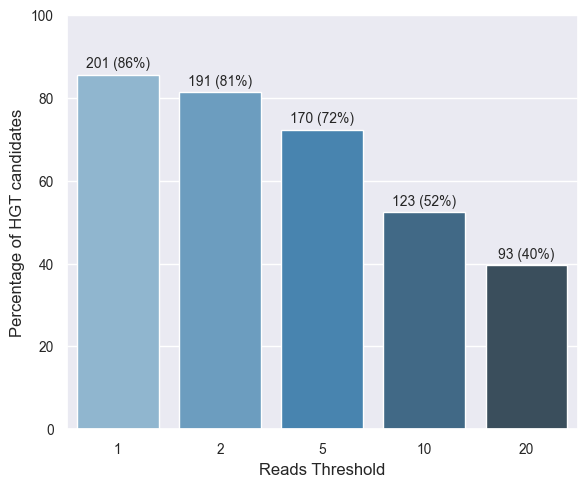

In [43]:
sns.set_theme(font_scale = 0.9, font = 'Arial',style = 'darkgrid')

df = pd.read_excel("D:/research_files/lichen metagenome/breakp_data_update.xlsx")
df['combined'] = df['Sample'].astype(str) + '_' + df['Gene'].astype(str) + '.t1'

df2 = pd.read_csv("target_gene_annotation2021.tsv", sep="\t")
df2 = df2[df2["confidence"] == 'high-confidence'].copy()
keyword = 'Refined'
df2['Gene'] = df2['Gene'].astype(str)
df2 = df2[df2['Gene'].str.contains(keyword, case=False, na=False)]
df2['Gene'] = df2['Gene'].str.replace(r'_Refined_\d+', '', regex=True)

df_sub = df[df['combined'].isin(df2['Gene'])]

def is_valid_hgt_breakpoint(row, crossing_reads_threshold):
    """
    判断单个断点是否可能是真实的HGT

    参数:
    row: 数据行
    crossing_reads_threshold: Crossing_reads的最小阈值

    返回:
    bool: 是否可能是真实的HGT
    """
    # 基本条件：足够的跨越读段
    if row['Crossing_reads'] < crossing_reads_threshold:
        return False

    # 覆盖度绝对值检查
    if row['Breakpoint_cov'] < 1 :  # 最小覆盖度要求
        return False

    # 覆盖度一致性检查
    cov_ratio = row['Breakpoint_cov'] / ((row['Left_cov'] + row['Right_cov']) / 2)
    if not (0.5 <= cov_ratio <= 2.0):  # 覆盖度应该在50%-200%范围内
        return False

    return True

results = []
thresholds = [1,2,5,10,20]
gene_dict = {}
for thr in thresholds:
    # 为每个断点添加有效性标记
    df_sub['is_valid'] = df_sub.apply(is_valid_hgt_breakpoint, axis=1, crossing_reads_threshold=thr)

    # 按Gene和Order分组，统计每个基因在两个order的有效性
    gene_validity = df_sub.groupby(['Gene', 'Order'])['is_valid'].any().unstack(fill_value=False)

    # 找出两个order都有效的基因
    both_valid_genes = gene_validity[(gene_validity[0] == True) & (gene_validity[1] == True)].index.tolist()

    total_genes = gene_validity.index.nunique()
    percent = len(both_valid_genes) / total_genes * 100

    results.append({'Threshold': thr, 'High_conf_HGT_genes': len(both_valid_genes),'Percent': percent})
    gene_dict[thr] = both_valid_genes

# 转成 DataFrame
plot_df = pd.DataFrame(results)
for thr in thresholds:
    print(f"\n=== Threshold {thr} ===")
    print(gene_dict[thr])

# 画柱状图
plt.figure(figsize=(6, 5))
bar_colors = sns.color_palette("Blues_d", len(plot_df))
sns.barplot(data=plot_df, x='Threshold', y='Percent', palette=bar_colors)
for index, row in plot_df.iterrows():
    hgt_num = int(row['High_conf_HGT_genes'])
    percent = row['Percent']
    plt.text(
        index,
        percent + 1,  # 稍微高于柱子
        f"{hgt_num} ({percent:.0f}%)",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xlabel('Reads Threshold', fontsize=12)
plt.ylabel('Percentage of HGT candidates', fontsize=12)
# plt.title('High-confidence HGT Genes under Different Crossing_reads Thresholds', fontsize=14)
plt.ylim(0, 100)
plt.tight_layout()
# plt.show()
plt.savefig('corssingreads_threshold_hc.png',dpi=300)